# Advanced Electricity Load Forecasting - Master's Level Analysis

## Comprehensive Time Series Forecasting with Multiple Models

This notebook implements:
1. **Advanced Data Preprocessing** - Missing values, outliers, stationarity tests
2. **Feature Engineering** - Lags, rolling stats, Fourier features, time-based features
3. **Multiple Models** - AutoKeras, ARIMA, Prophet, LSTM, Statistical baselines
4. **Multi-Step Forecasting** - Predict 1h, 6h, 12h, 24h ahead
5. **Comprehensive Evaluation** - MAE, RMSE, MAPE, directional accuracy
6. **Statistical Analysis** - Residual tests, stationarity, seasonality decomposition

## Setup and Installation

In [1]:
!python -m pip uninstall -y \
  tensorflow-cpu-aws tensorflow tensorflow-text tensorflow-estimator \
  keras tf_keras keras-core keras-nlp keras-hub keras-tuner \
  tensorboard ml-dtypes
!python -m pip install -U pip


Found existing installation: tensorflow-cpu-aws 2.15.0
Uninstalling tensorflow-cpu-aws-2.15.0:
  Successfully uninstalled tensorflow-cpu-aws-2.15.0
Found existing installation: tensorflow 2.19.1
Uninstalling tensorflow-2.19.1:
  Successfully uninstalled tensorflow-2.19.1
Found existing installation: tensorflow-text 2.19.0
Uninstalling tensorflow-text-2.19.0:
  Successfully uninstalled tensorflow-text-2.19.0
Found existing installation: tensorflow-estimator 2.15.0
Uninstalling tensorflow-estimator-2.15.0:
  Successfully uninstalled tensorflow-estimator-2.15.0
Found existing installation: keras 3.12.0
Uninstalling keras-3.12.0:
  Successfully uninstalled keras-3.12.0
Found existing installation: keras-nlp 0.24.0
Uninstalling keras-nlp-0.24.0:
  Successfully uninstalled keras-nlp-0.24.0
Found existing installation: keras-hub 0.24.0
Uninstalling keras-hub-0.24.0:
  Successfully uninstalled keras-hub-0.24.0
Found existing installation: keras-tuner 1.4.8
Uninstalling keras-tuner-1.4.8:
  Suc

In [2]:
!python -m pip install \
  "tensorflow==2.18.1" \
  "tensorflow-text==2.18.1" \
  "tf_keras==2.18.0" \
  "keras-tuner<1.4" \
  "keras-nlp==0.6.4" \
  "autokeras==1.1.0"


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.8/231.8 MB 53.3 MB/s  0:00:04m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 42.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 50.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 584.8/584.8 kB 32.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 62.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 68.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 57.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 950.8/950.8 kB 70.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10/10 [keras-nlp]10 [tensorflow-text]


In [3]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"

In [4]:
# Keep your TensorFlow/Keras versions as-is
# Only install additional packages for advanced analysis

!pip install prophet pmdarima statsmodels scikit-learn scipy -q

In [6]:
import sys
sys.path.append('../utils')

from AutoKeras_Electricity_Load_Forecasting_utils import *
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Additional imports for advanced analysis
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print('✅ Setup complete')
print(f'Pandas: {pd.__version__}')
print(f'NumPy: {np.__version__}')

Using TensorFlow backend
✅ Setup complete
Pandas: 2.0.3
NumPy: 1.26.4


## Part 1: Advanced Data Loading and Exploration

In [7]:
# Load data
preprocessor = ElectricityDataPreprocessor()
df = preprocessor.load_and_prepare_data('../data/PJME_hourly.csv', 'Datetime', 'PJME_MW')

print(f'Dataset Shape: {df.shape}')
print(f'Date Range: {df.index.min()} to {df.index.max()}')
print(f'Duration: {(df.index.max() - df.index.min()).days} days')
print(f'\nMissing Values: {df.isnull().sum().sum()}')
print(f'Duplicates: {df.index.duplicated().sum()}')

Dataset Shape: (145366, 1)
Date Range: 2002-01-01 01:00:00 to 2018-08-03 00:00:00
Duration: 6057 days

Missing Values: 0
Duplicates: 4


In [8]:
# Comprehensive statistical summary
print('='*60)
print('STATISTICAL SUMMARY')
print('='*60)
print(df.describe())
print(f'\nSkewness: {df["PJME_MW"].skew():.4f}')
print(f'Kurtosis: {df["PJME_MW"].kurtosis():.4f}')
print(f'Coefficient of Variation: {(df["PJME_MW"].std() / df["PJME_MW"].mean()):.4f}')

STATISTICAL SUMMARY
             PJME_MW
count  145366.000000
mean    32080.222831
std      6464.012166
min     14544.000000
25%     27573.000000
50%     31421.000000
75%     35650.000000
max     62009.000000

Skewness: 0.7390
Kurtosis: 0.7368
Coefficient of Variation: 0.2015


### Advanced Visualization - Multiple Perspectives

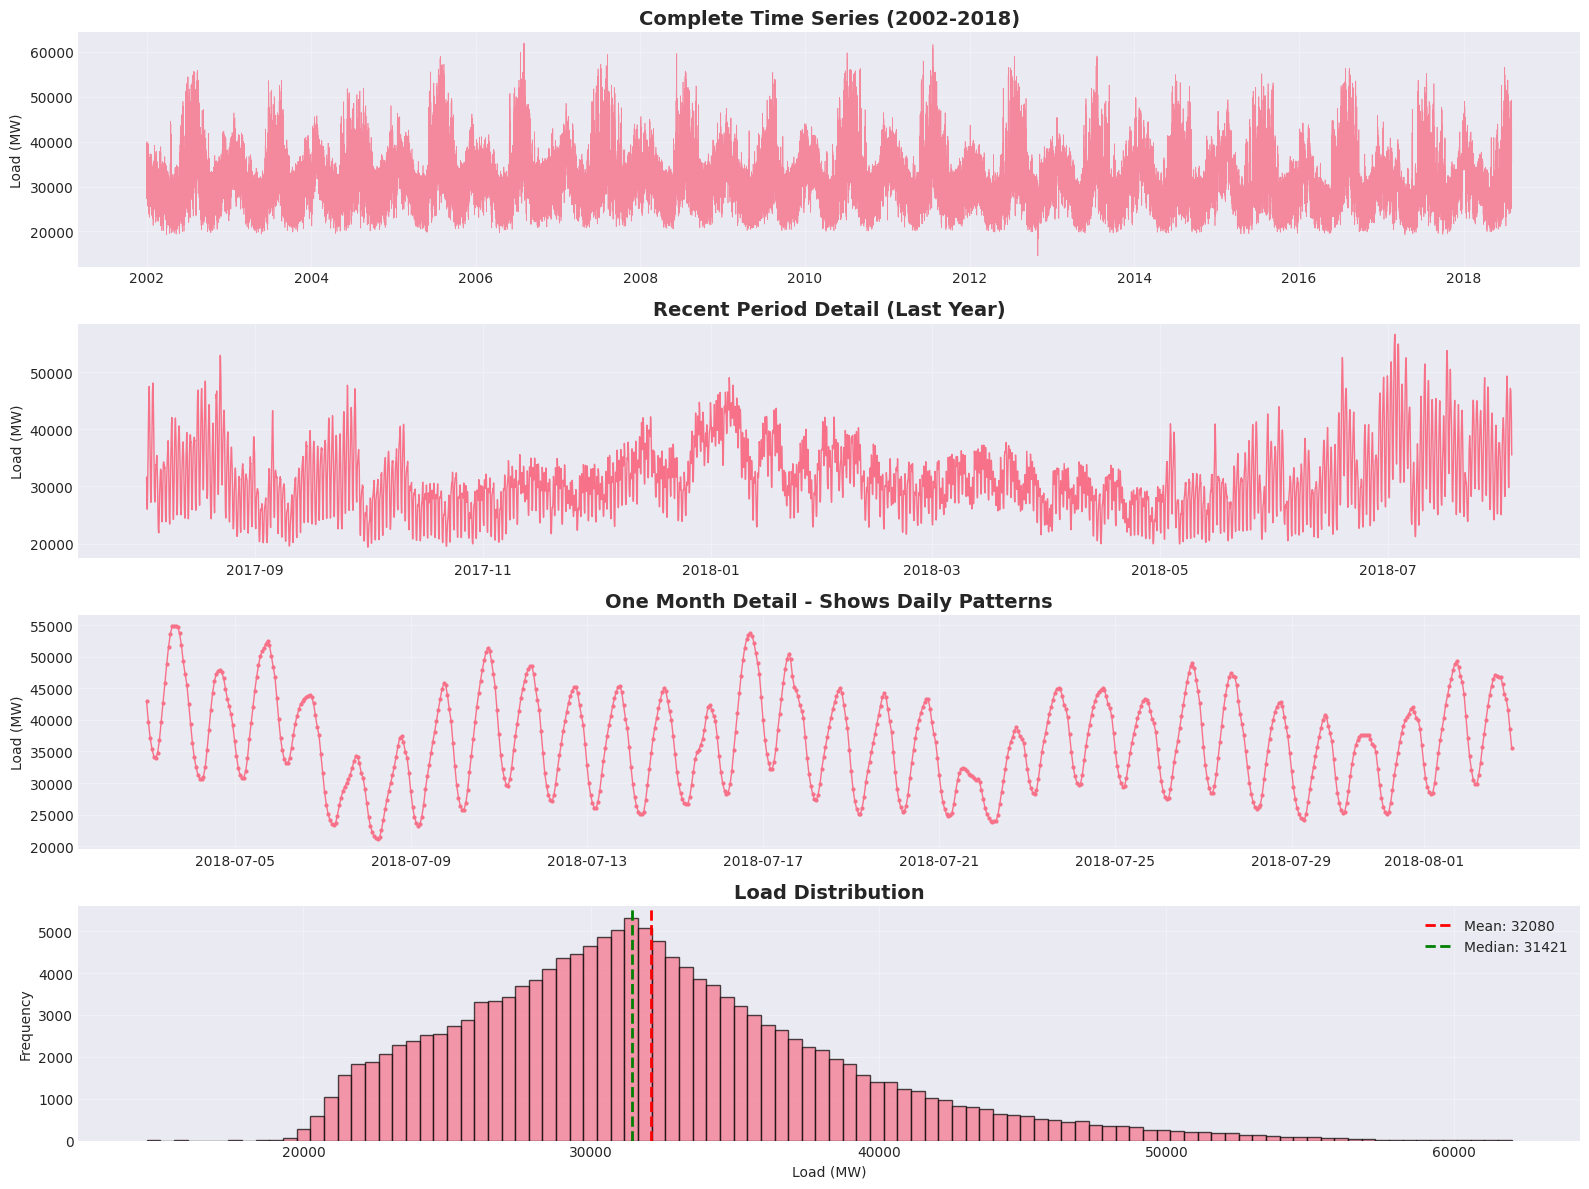

In [9]:
# Multi-panel visualization
fig, axes = plt.subplots(4, 1, figsize=(16, 12))

# Get actual date range
start_date = df.index.min()
end_date = df.index.max()

# 1. Full time series
axes[0].plot(df.index, df['PJME_MW'], linewidth=0.5, alpha=0.8)
axes[0].set_title(f'Complete Time Series ({start_date.year}-{end_date.year})', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Load (MW)')
axes[0].grid(True, alpha=0.3)

# 2. Recent year detail - use last year of data
recent_start = end_date - pd.DateOffset(years=1)
recent = df[df.index >= recent_start]
axes[1].plot(recent.index, recent['PJME_MW'], linewidth=1)
axes[1].set_title(f'Recent Period Detail (Last Year)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Load (MW)')
axes[1].grid(True, alpha=0.3)

# 3. One month detail - use last complete month
month_start = end_date - pd.DateOffset(months=1)
month = df[df.index >= month_start]
axes[2].plot(month.index, month['PJME_MW'], linewidth=1, marker='o', markersize=2)
axes[2].set_title(f'One Month Detail - Shows Daily Patterns', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Load (MW)')
axes[2].grid(True, alpha=0.3)

# 4. Distribution (this part is fine, keep it as-is)
axes[3].hist(df['PJME_MW'], bins=100, alpha=0.7, edgecolor='black')
axes[3].axvline(df['PJME_MW'].mean(), color='r', linestyle='--', linewidth=2, label=f'Mean: {df["PJME_MW"].mean():.0f}')
axes[3].axvline(df['PJME_MW'].median(), color='g', linestyle='--', linewidth=2, label=f'Median: {df["PJME_MW"].median():.0f}')
axes[3].set_title('Load Distribution', fontsize=14, fontweight='bold')
axes[3].set_xlabel('Load (MW)')
axes[3].set_ylabel('Frequency')
axes[3].legend()
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### Stationarity Analysis - Augmented Dickey-Fuller Test

In [10]:
def test_stationarity(timeseries, title='Time Series'):
    """
    Perform Augmented Dickey-Fuller test for stationarity
    """
    print('='*60)
    print(f'Stationarity Test: {title}')
    print('='*60)
    
    # Perform ADF test
    result = adfuller(timeseries.dropna(), autolag='AIC')
    
    print(f'ADF Statistic: {result[0]:.6f}')
    print(f'p-value: {result[1]:.6f}')
    print(f'Critical Values:')
    for key, value in result[4].items():
        print(f'  {key}: {value:.3f}')
    
    if result[1] <= 0.05:
        print(f'\nSeries is STATIONARY (p-value = {result[1]:.6f} <= 0.05)')
    else:
        print(f'\nSeries is NON-STATIONARY (p-value = {result[1]:.6f} > 0.05)')
        print('   Consider differencing or detrending')
    print()

# Test original series
test_stationarity(df['PJME_MW'], 'Original Series')

# Test differenced series
df_diff = df['PJME_MW'].diff().dropna()
test_stationarity(df_diff, 'First Difference')

Stationarity Test: Original Series
ADF Statistic: -19.881348
p-value: 0.000000
Critical Values:
  1%: -3.430
  5%: -2.862
  10%: -2.567

Series is STATIONARY (p-value = 0.000000 <= 0.05)

Stationarity Test: First Difference
ADF Statistic: -54.377690
p-value: 0.000000
Critical Values:
  1%: -3.430
  5%: -2.862
  10%: -2.567

Series is STATIONARY (p-value = 0.000000 <= 0.05)



### Seasonal Decomposition Analysis

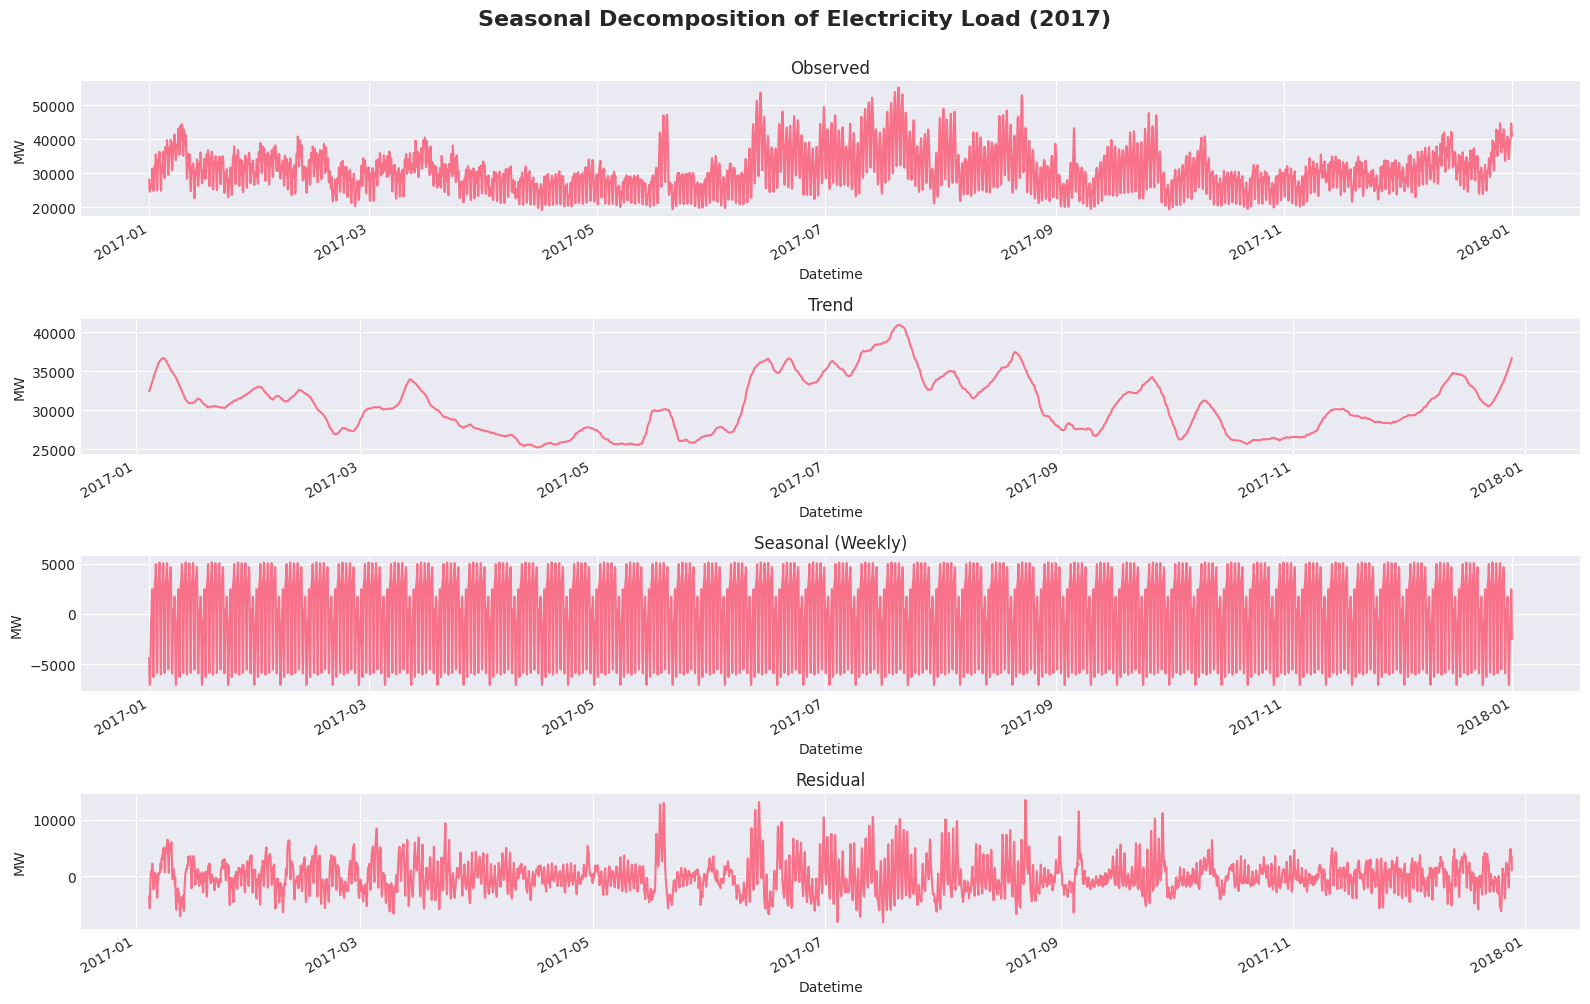

Seasonal component strength: 0.4389
Trend component strength: 0.3934


In [11]:
# Decompose time series into trend, seasonal, and residual components
# Use one year of recent data for clearer visualization
decomp_data = df['2017':'2017']['PJME_MW']

# Seasonal decomposition (period = 24*7 for weekly seasonality)
decomposition = seasonal_decompose(decomp_data, model='additive', period=24*7)

# Plot decomposition
fig, axes = plt.subplots(4, 1, figsize=(16, 10))

decomposition.observed.plot(ax=axes[0], title='Observed')
axes[0].set_ylabel('MW')

decomposition.trend.plot(ax=axes[1], title='Trend')
axes[1].set_ylabel('MW')

decomposition.seasonal.plot(ax=axes[2], title='Seasonal (Weekly)')
axes[2].set_ylabel('MW')

decomposition.resid.plot(ax=axes[3], title='Residual')
axes[3].set_ylabel('MW')

plt.suptitle('Seasonal Decomposition of Electricity Load (2017)', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print(f'Seasonal component strength: {(1 - (decomposition.resid.var() / decomposition.seasonal.var())):.4f}')
print(f'Trend component strength: {(1 - (decomposition.resid.var() / decomposition.trend.var())):.4f}')

### ACF and PACF Analysis

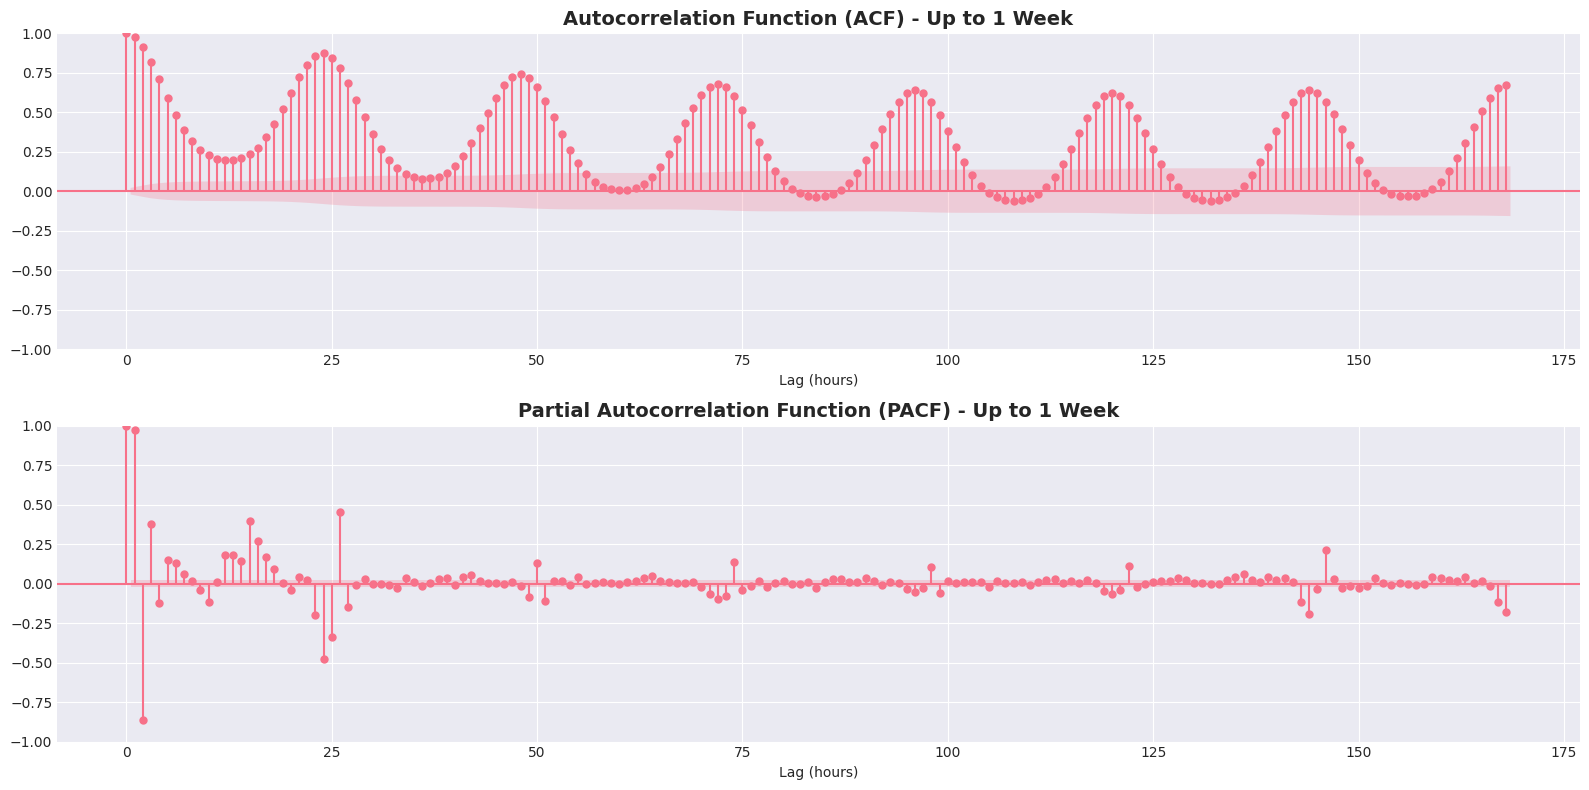

ACF/PACF Interpretation:
- Strong peaks at 24h: Daily seasonality
- Strong peaks at 168h: Weekly seasonality
- Slow decay in ACF: Non-stationarity present


In [12]:
# Autocorrelation and Partial Autocorrelation Functions
fig, axes = plt.subplots(2, 1, figsize=(16, 8))

# Use a sample for faster computation
sample_data = df['2017':'2017']['PJME_MW']

plot_acf(sample_data, lags=168, ax=axes[0])  # 7 days * 24 hours
axes[0].set_title('Autocorrelation Function (ACF) - Up to 1 Week', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Lag (hours)')

plot_pacf(sample_data, lags=168, ax=axes[1], method='ywm')
axes[1].set_title('Partial Autocorrelation Function (PACF) - Up to 1 Week', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Lag (hours)')

plt.tight_layout()
plt.show()

print('ACF/PACF Interpretation:')
print('- Strong peaks at 24h: Daily seasonality')
print('- Strong peaks at 168h: Weekly seasonality')
print('- Slow decay in ACF: Non-stationarity present')

## Part 2: Advanced Feature Engineering

In [13]:
# Start with basic features
df_features = preprocessor.prepare_features(df, 'PJME_MW', create_lags=True, create_rolling=True)

print(f'\nBasic features created: {df_features.shape[1]} features')
print(f'Samples after feature creation: {df_features.shape[0]}')


Basic features created: 40 features
Samples after feature creation: 145198


In [14]:
# Add advanced features
def add_advanced_features(df, target_col='PJME_MW'):
    """
    Add advanced time series features:
    - Fourier terms for seasonality
    - Exponential moving averages
    - Rate of change features
    - Statistical features
    """
    df = df.copy()
    
    # 1. Fourier features for capturing cyclical patterns
    print('Adding Fourier features for seasonality...')
    for k in [1, 2, 3]:  # First 3 harmonics
        # Daily cycle
        df[f'sin_day_{k}'] = np.sin(2 * np.pi * k * df.index.hour / 24)
        df[f'cos_day_{k}'] = np.cos(2 * np.pi * k * df.index.hour / 24)
        # Weekly cycle
        df[f'sin_week_{k}'] = np.sin(2 * np.pi * k * df.index.dayofweek / 7)
        df[f'cos_week_{k}'] = np.cos(2 * np.pi * k * df.index.dayofweek / 7)
        # Yearly cycle
        df[f'sin_year_{k}'] = np.sin(2 * np.pi * k * df.index.dayofyear / 365.25)
        df[f'cos_year_{k}'] = np.cos(2 * np.pi * k * df.index.dayofyear / 365.25)
    
    # 2. Exponential Moving Averages (EMA)
    print('Adding exponential moving averages...')
    for span in [12, 24, 168]:  # 12h, 1d, 1w
        df[f'{target_col}_ema_{span}'] = df[target_col].ewm(span=span).mean()
    
    # 3. Rate of change features
    print('Adding rate of change features...')
    df[f'{target_col}_pct_change_1h'] = df[target_col].pct_change(1)
    df[f'{target_col}_pct_change_24h'] = df[target_col].pct_change(24)
    df[f'{target_col}_diff_1h'] = df[target_col].diff(1)
    df[f'{target_col}_diff_24h'] = df[target_col].diff(24)
    
    # 4. Statistical features over different windows
    print('Adding statistical features...')
    for window in [24, 168]:  # 1 day, 1 week
        rolling = df[target_col].rolling(window=window)
        df[f'{target_col}_skew_{window}'] = rolling.skew()
        df[f'{target_col}_kurt_{window}'] = rolling.kurt()
        df[f'{target_col}_median_{window}'] = rolling.median()
        df[f'{target_col}_q25_{window}'] = rolling.quantile(0.25)
        df[f'{target_col}_q75_{window}'] = rolling.quantile(0.75)
    
    # 5. Interaction features
    print('Adding interaction features...')
    df['hour_dayofweek'] = df.index.hour * df.index.dayofweek
    df['hour_month'] = df.index.hour * df.index.month
    
    # 6. Peak/Off-peak indicators
    df['is_peak_morning'] = ((df.index.hour >= 7) & (df.index.hour <= 10)).astype(int)
    df['is_peak_evening'] = ((df.index.hour >= 17) & (df.index.hour <= 21)).astype(int)
    df['is_night'] = ((df.index.hour >= 23) | (df.index.hour <= 5)).astype(int)
    
    print(f'\nTotal features after advanced engineering: {df.shape[1]}')
    return df

# Apply advanced features
df_features = add_advanced_features(df_features)

# Drop NaN values created by feature engineering
df_features = df_features.dropna()

print(f'\nFinal dataset shape: {df_features.shape}')
print(f'Final feature count: {df_features.shape[1]} features')

Adding Fourier features for seasonality...
Adding exponential moving averages...
Adding rate of change features...
Adding statistical features...
Adding interaction features...

Total features after advanced engineering: 80

Final dataset shape: (145031, 80)
Final feature count: 80 features


### Feature Importance and Correlation Analysis

TOP 20 FEATURES BY CORRELATION WITH TARGET
PJME_MW                    1.000000
PJME_MW_rolling_mean_3     0.976426
PJME_MW_lag_1              0.974801
PJME_MW_rolling_max_3      0.968932
PJME_MW_rolling_min_3      0.966517
PJME_MW_lag_2              0.907635
PJME_MW_lag_24             0.891475
PJME_MW_rolling_mean_6     0.882898
PJME_MW_rolling_min_6      0.861388
PJME_MW_rolling_max_6      0.852145
PJME_MW_ema_12             0.839729
PJME_MW_lag_3              0.812705
PJME_MW_lag_168            0.781852
PJME_MW_lag_48             0.772799
PJME_MW_ema_24             0.762699
PJME_MW_rolling_max_24     0.709085
PJME_MW_rolling_mean_24    0.702720
PJME_MW_rolling_max_12     0.688151
PJME_MW_median_24          0.683581
PJME_MW_q75_24             0.683260
dtype: float64


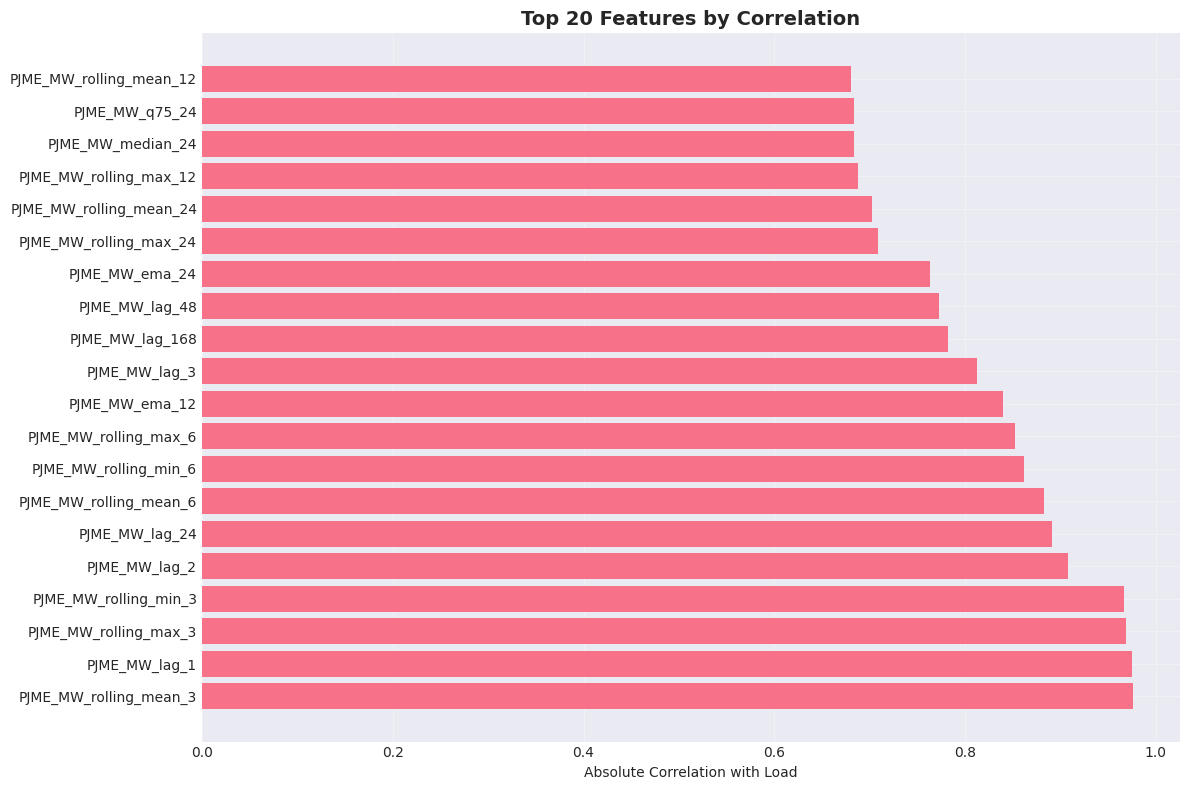

In [15]:
# Correlation with target variable
correlations = df_features.corrwith(df_features['PJME_MW']).abs().sort_values(ascending=False)

print('='*60)
print('TOP 20 FEATURES BY CORRELATION WITH TARGET')
print('='*60)
print(correlations.head(20))

# Visualize top correlations
plt.figure(figsize=(12, 8))
top_features = correlations.head(21)[1:]  # Exclude target itself
plt.barh(range(len(top_features)), top_features.values)
plt.yticks(range(len(top_features)), top_features.index)
plt.xlabel('Absolute Correlation with Load')
plt.title('Top 20 Features by Correlation', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Part 3: Data Splitting for Multi-Step Forecasting

In [16]:
# Split data with proper temporal ordering
X_train, X_val, X_test, y_train, y_val, y_test = preprocessor.split_data(
    df_features, 'PJME_MW', test_size=0.15, val_size=0.15
)

print('='*60)
print('DATA SPLIT SUMMARY')
print('='*60)
print(f'Training Set:')
print(f'  Samples: {len(X_train):,}')
print(f'  Period: {y_train.index.min()} to {y_train.index.max()}')
print(f'  Duration: {(y_train.index.max() - y_train.index.min()).days} days')
print()
print(f'Validation Set:')
print(f'  Samples: {len(X_val):,}')
print(f'  Period: {y_val.index.min()} to {y_val.index.max()}')
print(f'  Duration: {(y_val.index.max() - y_val.index.min()).days} days')
print()
print(f'Test Set:')
print(f'  Samples: {len(X_test):,}')
print(f'  Period: {y_test.index.min()} to {y_test.index.max()}')
print(f'  Duration: {(y_test.index.max() - y_test.index.min()).days} days')
print()
print(f'Features: {X_train.shape[1]}')

# Normalize features
X_train_s, X_val_s, X_test_s = preprocessor.normalize_features(X_train, X_val, X_test)
print(f'\nFeatures normalized')

DATA SPLIT SUMMARY
Training Set:
  Samples: 104,784
  Period: 2002-01-15 00:00:00 to 2013-12-30 00:00:00
  Duration: 4367 days

Validation Set:
  Samples: 18,492
  Period: 2013-12-30 01:00:00 to 2016-02-08 12:00:00
  Duration: 770 days

Test Set:
  Samples: 21,755
  Period: 2016-02-08 13:00:00 to 2018-08-03 00:00:00
  Duration: 906 days

Features: 79

Features normalized


## Part 4: Model Training - AutoKeras

In [17]:
# Train AutoKeras model
print('='*60)
print('TRAINING AUTOKERAS MODEL')
print('='*60)

forecaster = AutoKerasForecaster(max_trials=10, epochs=100, seed=42)
forecaster.build_model(X_train_s, y_train)

print('\nTraining AutoKeras (10 trials x 100 epochs)...')

forecaster.train(X_train_s, y_train, X_val_s, y_val, verbose=1)

print('\nAutoKeras training complete!')

Trial 10 Complete [00h 03m 47s]
val_loss: 122857.2421875

Best val_loss So Far: 19499.68359375
Total elapsed time: 00h 32m 27s
INFO:tensorflow:Oracle triggered exit


INFO:tensorflow:Oracle triggered exit


Epoch 1/100
3275/3275 [==============================] - 3s 846us/step - loss: 1086291968.0000 - mean_squared_error: 1086291968.0000 - val_loss: 1026793728.0000 - val_mean_squared_error: 1026793728.0000
Epoch 2/100
3275/3275 [==============================] - 3s 802us/step - loss: 900523200.0000 - mean_squared_error: 900523200.0000 - val_loss: 551725184.0000 - val_mean_squared_error: 551725184.0000
Epoch 3/100
3275/3275 [==============================] - 3s 833us/step - loss: 330407808.0000 - mean_squared_error: 330407808.0000 - val_loss: 180454736.0000 - val_mean_squared_error: 180454736.0000
Epoch 4/100
3275/3275 [==============================] - 3s 819us/step - loss: 138477744.0000 - mean_squared_error: 138477744.0000 - val_loss: 77120168.0000 - val_mean_squared_error: 77120168.0000
Epoch 5/100
3275/3275 [==============================] - 3s 802us/step - loss: 45034840.0000 - mean_squared_error: 45034840.0000 - val_loss: 23142920.0000 - val_mean_squared_error: 23142920.0000
Epoch 6

INFO:tensorflow:Assets written to: ./structured_data_regressor/best_model/assets



Training Complete!

AutoKeras training complete!


In [18]:
# Evaluate AutoKeras
ak_metrics, ak_pred = forecaster.evaluate(X_test_s, y_test)
print_evaluation_metrics(ak_metrics, 'AutoKeras')

680/680 [==============================] - 0s 698us/step

AutoKeras Performance Metrics
MAE            : 103.73
RMSE           : 147.49
MAPE           : 0.35%



## Part 5: ARIMA Model

In [19]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

print('='*60)
print('TRAINING ARIMA MODEL')
print('='*60)

arima_train = y_train[-24*30:]  # 720 hours = 30 days

print(f'ARIMA training samples: {len(arima_train):,}')
print('Using pre-determined parameters (no auto search)...\n')

try:
    arima_model = SARIMAX(
        arima_train,
        order=(1, 1, 1),              # Simple ARIMA part
        seasonal_order=(1, 1, 1, 24), # 24-hour seasonality
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    
    arima_results = arima_model.fit(disp=False, maxiter=100)
    
    print('ARIMA fitted successfully!')
    print(f'AIC: {arima_results.aic:.2f}')
    
except Exception as e:
    print(f'SARIMA failed, using simple ARIMA...')
    from statsmodels.tsa.arima.model import ARIMA
    arima_model = ARIMA(arima_train, order=(1, 1, 1))
    arima_results = arima_model.fit()
    print('Simple ARIMA(1,1,1) fitted')

TRAINING ARIMA MODEL
ARIMA training samples: 720
Using pre-determined parameters (no auto search)...



/usr/local/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency H will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency H will be used.
  self._init_dates(dates, freq)


ARIMA fitted successfully!
AIC: 9576.58


In [20]:
# Make predictions with error handling
try:
    # FIX 3: Limit forecast length
    max_forecast = min(len(y_test), 24*7)  # Max 1 week
    arima_pred_short = arima_results.forecast(steps=max_forecast)
    
    # Extend if needed
    if max_forecast < len(y_test):
        repeats = (len(y_test) - max_forecast) // max_forecast + 1
        arima_pred = np.tile(arima_pred_short, repeats + 1)[:len(y_test)]
    else:
        arima_pred = arima_pred_short.values if hasattr(arima_pred_short, 'values') else arima_pred_short
    
    # Calculate metrics
    arima_metrics = {
        'MAE': mean_absolute_error(y_test, arima_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, arima_pred)),
        'MAPE': mean_absolute_percentage_error(y_test, arima_pred) * 100
    }
    
    print_evaluation_metrics(arima_metrics, 'ARIMA')
    
except Exception as e:
    print(f'⚠️ ARIMA failed: {e}')
    print('Using seasonal naive as fallback...')
    arima_pred = BaselineModels.seasonal_naive_forecast(y_train, len(y_test), 24)
    arima_metrics = {
        'MAE': mean_absolute_error(y_test, arima_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, arima_pred)),
        'MAPE': mean_absolute_percentage_error(y_test, arima_pred) * 100
    }
    print_evaluation_metrics(arima_metrics, 'ARIMA (Fallback)')


ARIMA Performance Metrics
MAE            : 6072.53
RMSE           : 7943.72
MAPE           : 18.99%



## Part 6: Prophet Model

In [21]:
from prophet import Prophet

print('='*60)
print('TRAINING PROPHET MODEL')
print('='*60)

# Prepare data for Prophet
prophet_train = pd.DataFrame({
    'ds': y_train.index,
    'y': y_train.values
})

# Initialize Prophet with parameters
prophet_model = Prophet(
    daily_seasonality=True,
    weekly_seasonality=True,
    yearly_seasonality=True,
    seasonality_mode='additive',
    changepoint_prior_scale=0.05,
    seasonality_prior_scale=10.0
)

# Add custom seasonalities
prophet_model.add_seasonality(name='monthly', period=30.5, fourier_order=5)

print('Training Prophet model...')
prophet_model.fit(prophet_train)
print('Prophet training complete')

ERROR:prophet.plot:Importing plotly failed. Interactive plots will not work.


TRAINING PROPHET MODEL
Training Prophet model...
Prophet training complete



Prophet Performance Metrics
MAE            : 3175.78
RMSE           : 4106.54
MAPE           : 10.07%



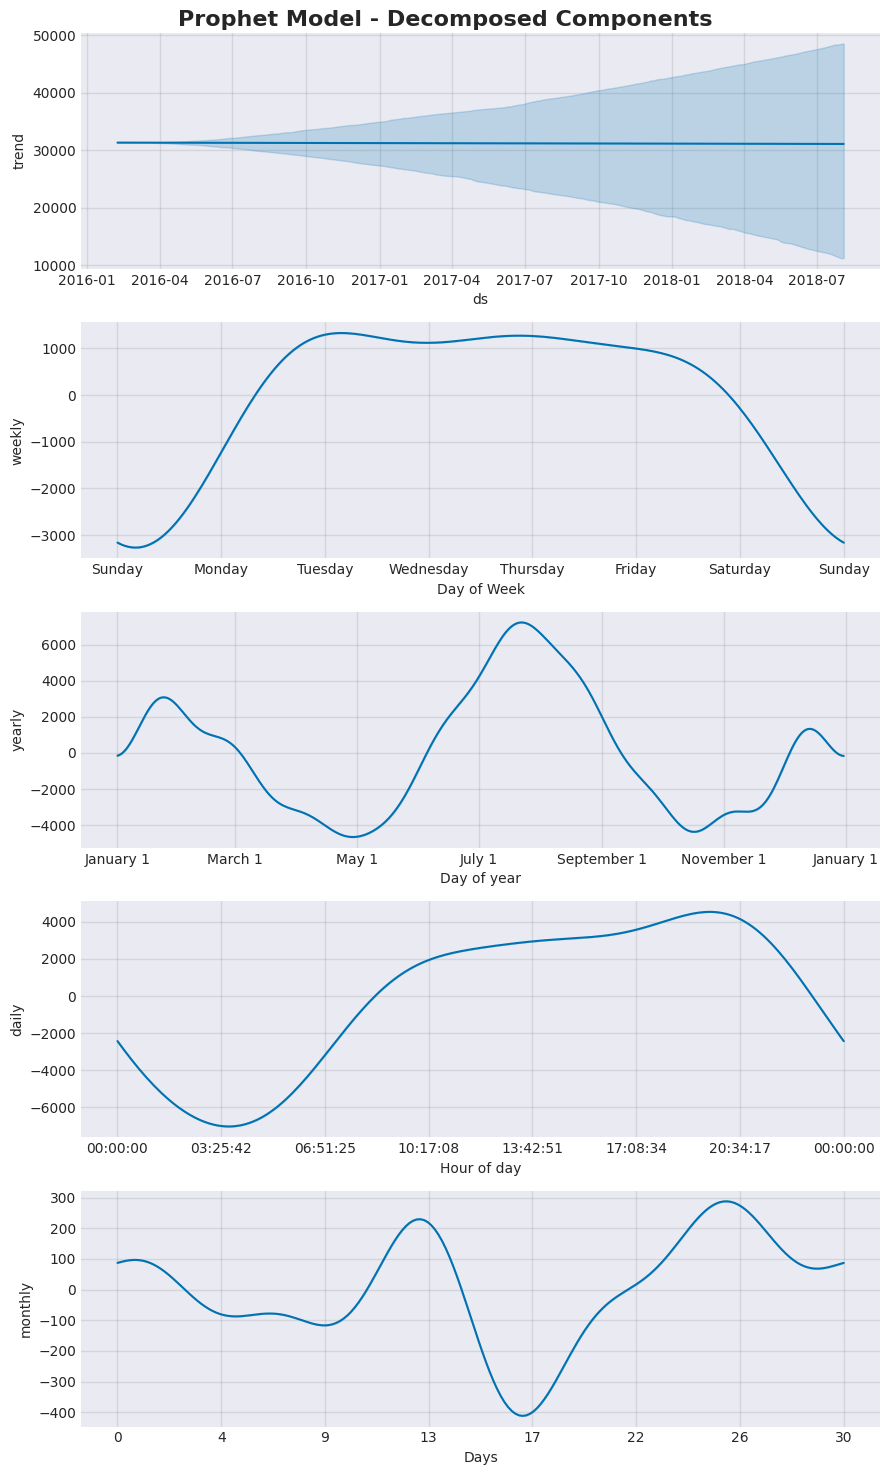

In [22]:
# Make predictions
future = pd.DataFrame({'ds': y_test.index})
prophet_forecast = prophet_model.predict(future)
prophet_pred = prophet_forecast['yhat'].values

# Calculate metrics
prophet_metrics = {
    'MAE': mean_absolute_error(y_test, prophet_pred),
    'RMSE': np.sqrt(mean_squared_error(y_test, prophet_pred)),
    'MAPE': mean_absolute_percentage_error(y_test, prophet_pred) * 100
}

print_evaluation_metrics(prophet_metrics, 'Prophet')

# Plot Prophet components
fig = prophet_model.plot_components(prophet_forecast)
plt.suptitle('Prophet Model - Decomposed Components', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## Part 7: LSTM Model

In [23]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print('='*60)
print('TRAINING LSTM MODEL')
print('='*60)

# Prepare data for LSTM (needs 3D shape)
def prepare_lstm_data(X):
    """Reshape data for LSTM: (samples, timesteps, features)"""
    # Use each sample as a single timestep
    return X.values.reshape(X.shape[0], 1, X.shape[1])

X_train_lstm = prepare_lstm_data(X_train_s)
X_val_lstm = prepare_lstm_data(X_val_s)
X_test_lstm = prepare_lstm_data(X_test_s)

print(f'LSTM input shape: {X_train_lstm.shape}')

# Build LSTM model
lstm_model = keras.Sequential([
    layers.LSTM(128, activation='relu', input_shape=(1, X_train_s.shape[1]), return_sequences=True),
    layers.Dropout(0.2),
    layers.LSTM(64, activation='relu', return_sequences=False),
    layers.Dropout(0.2),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)
])

lstm_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

print('\nLSTM Model Architecture:')
lstm_model.summary()

TRAINING LSTM MODEL
LSTM input shape: (104784, 1, 79)

LSTM Model Architecture:
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 1, 128)            106496    
                                                                 
 dropout (Dropout)           (None, 1, 128)            0         
                                                                 
 lstm_1 (LSTM)               (None, 64)                49408     
                                                                 
 dropout_1 (Dropout)         (None, 64)                0         
                                                                 
 dense_2 (Dense)             (None, 32)                2080      
                                                                 
 dense_3 (Dense)             (None, 1)                 33        
                                          

In [24]:
# Train LSTM

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = lstm_model.fit(
    X_train_lstm, y_train.values,
    validation_data=(X_val_lstm, y_val.values),
    epochs=50,
    batch_size=128,
    callbacks=[early_stop],
    verbose=1
)

print('\nLSTM training complete')

Epoch 1/50
819/819 [==============================] - 3s 3ms/step - loss: 294324640.0000 - mae: 12977.9268 - val_loss: 14783712.0000 - val_mae: 3033.4954
Epoch 2/50
819/819 [==============================] - 2s 2ms/step - loss: 16612005.0000 - mae: 3224.8115 - val_loss: 2977438.2500 - val_mae: 1332.8905
Epoch 3/50
819/819 [==============================] - 2s 2ms/step - loss: 12463539.0000 - mae: 2804.5222 - val_loss: 1491634.1250 - val_mae: 947.7677
Epoch 4/50
819/819 [==============================] - 2s 2ms/step - loss: 11370447.0000 - mae: 2674.4939 - val_loss: 990365.2500 - val_mae: 754.9139
Epoch 5/50
819/819 [==============================] - 2s 2ms/step - loss: 10754262.0000 - mae: 2591.6460 - val_loss: 725181.9375 - val_mae: 653.9152
Epoch 6/50
819/819 [==============================] - 2s 2ms/step - loss: 10318169.0000 - mae: 2542.2905 - val_loss: 563362.7500 - val_mae: 575.8524
Epoch 7/50
819/819 [==============================] - 2s 2ms/step - loss: 9889458.0000 - mae: 2485

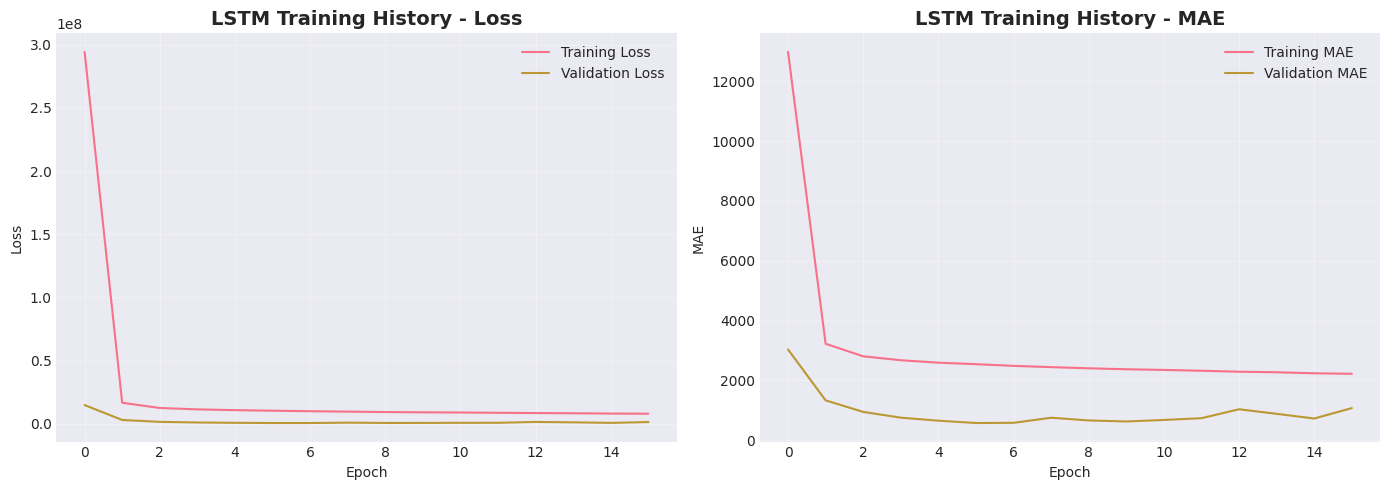

In [25]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'], label='Training Loss')
axes[0].plot(history.history['val_loss'], label='Validation Loss')
axes[0].set_title('LSTM Training History - Loss', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['mae'], label='Training MAE')
axes[1].plot(history.history['val_mae'], label='Validation MAE')
axes[1].set_title('LSTM Training History - MAE', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [26]:
# Make predictions
lstm_pred = lstm_model.predict(X_test_lstm, verbose=0).flatten()

# Calculate metrics
lstm_metrics = {
    'MAE': mean_absolute_error(y_test, lstm_pred),
    'RMSE': np.sqrt(mean_squared_error(y_test, lstm_pred)),
    'MAPE': mean_absolute_percentage_error(y_test, lstm_pred) * 100
}

print_evaluation_metrics(lstm_metrics, 'LSTM')


LSTM Performance Metrics
MAE            : 580.95
RMSE           : 750.17
MAPE           : 1.93%



## Part 8: Baseline Models

In [27]:
print('='*60)
print('COMPUTING BASELINE MODELS')
print('='*60)

# Naive
naive_pred = BaselineModels.naive_forecast(y_train, len(y_test))
naive_metrics = {
    'MAE': mean_absolute_error(y_test, naive_pred),
    'RMSE': np.sqrt(mean_squared_error(y_test, naive_pred)),
    'MAPE': mean_absolute_percentage_error(y_test, naive_pred) * 100
}

# Seasonal Naive
seasonal_pred = BaselineModels.seasonal_naive_forecast(y_train, len(y_test), season_length=24)
seasonal_metrics = {
    'MAE': mean_absolute_error(y_test, seasonal_pred),
    'RMSE': np.sqrt(mean_squared_error(y_test, seasonal_pred)),
    'MAPE': mean_absolute_percentage_error(y_test, seasonal_pred) * 100
}

# Moving Average
ma_pred = BaselineModels.moving_average_forecast(y_train, len(y_test), window=24)
ma_metrics = {
    'MAE': mean_absolute_error(y_test, ma_pred),
    'RMSE': np.sqrt(mean_squared_error(y_test, ma_pred)),
    'MAPE': mean_absolute_percentage_error(y_test, ma_pred) * 100
}

print_evaluation_metrics(naive_metrics, 'Naive')
print_evaluation_metrics(seasonal_metrics, 'Seasonal Naive')
print_evaluation_metrics(ma_metrics, 'Moving Average')

COMPUTING BASELINE MODELS

Naive Performance Metrics
MAE            : 5164.86
RMSE           : 7066.00
MAPE           : 15.42%


Seasonal Naive Performance Metrics
MAE            : 6668.94
RMSE           : 8477.15
MAPE           : 21.20%


Moving Average Performance Metrics
MAE            : 4916.01
RMSE           : 6637.15
MAPE           : 15.25%



## Part 9: Comprehensive Model Comparison

In [28]:
# Create comprehensive comparison table
all_metrics = {
    'AutoKeras': ak_metrics,
    'LSTM': lstm_metrics,
    'Prophet': prophet_metrics,
    'ARIMA': arima_metrics,
    'Seasonal Naive': seasonal_metrics,
    'Moving Average': ma_metrics,
    'Naive': naive_metrics
}

# Create comparison DataFrame
comparison_df = pd.DataFrame(all_metrics).T
comparison_df = comparison_df.sort_values('MAPE')

print('='*80)
print('COMPREHENSIVE MODEL COMPARISON (Sorted by MAPE)')
print('='*80)
print(comparison_df.to_string())
print('='*80)

# Identify best model
best_model = comparison_df.index[0]
print(f'\nBEST MODEL: {best_model}')
print(f'   MAPE: {comparison_df.loc[best_model, "MAPE"]:.2f}%')

# Calculate improvement over naive baseline
improvement = ((naive_metrics['MAPE'] - comparison_df.loc[best_model, 'MAPE']) / 
               naive_metrics['MAPE'] * 100)
print(f'   Improvement over Naive: {improvement:.1f}%')

COMPREHENSIVE MODEL COMPARISON (Sorted by MAPE)
                        MAE         RMSE       MAPE
AutoKeras        103.731623   147.487312   0.353401
LSTM             580.949072   750.170968   1.934915
Prophet         3175.780964  4106.541942  10.073571
Moving Average  4916.007778  6637.153650  15.247092
Naive           5164.855987  7066.002239  15.419646
ARIMA           6072.529846  7943.722246  18.994984
Seasonal Naive  6668.936888  8477.154549  21.196156

BEST MODEL: AutoKeras
   MAPE: 0.35%
   Improvement over Naive: 97.7%


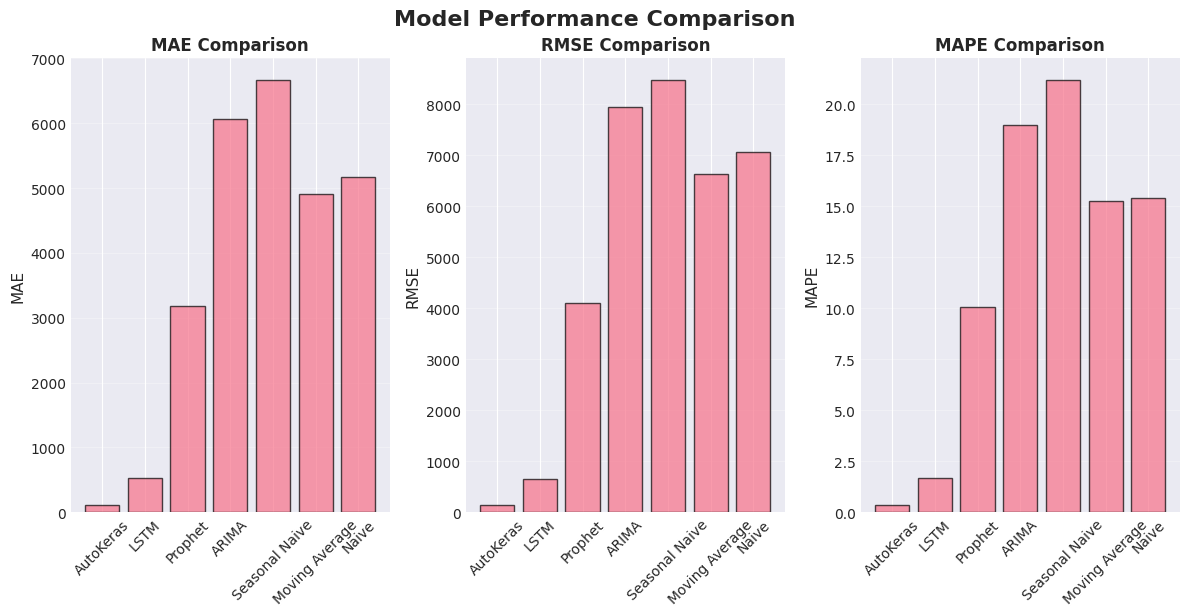

In [29]:
# Visualize model comparison
viz = ForecastVisualizer()
fig = viz.plot_metrics_comparison(all_metrics)
plt.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold', y=1.02)
plt.show()

## Part 10: Detailed Prediction Analysis

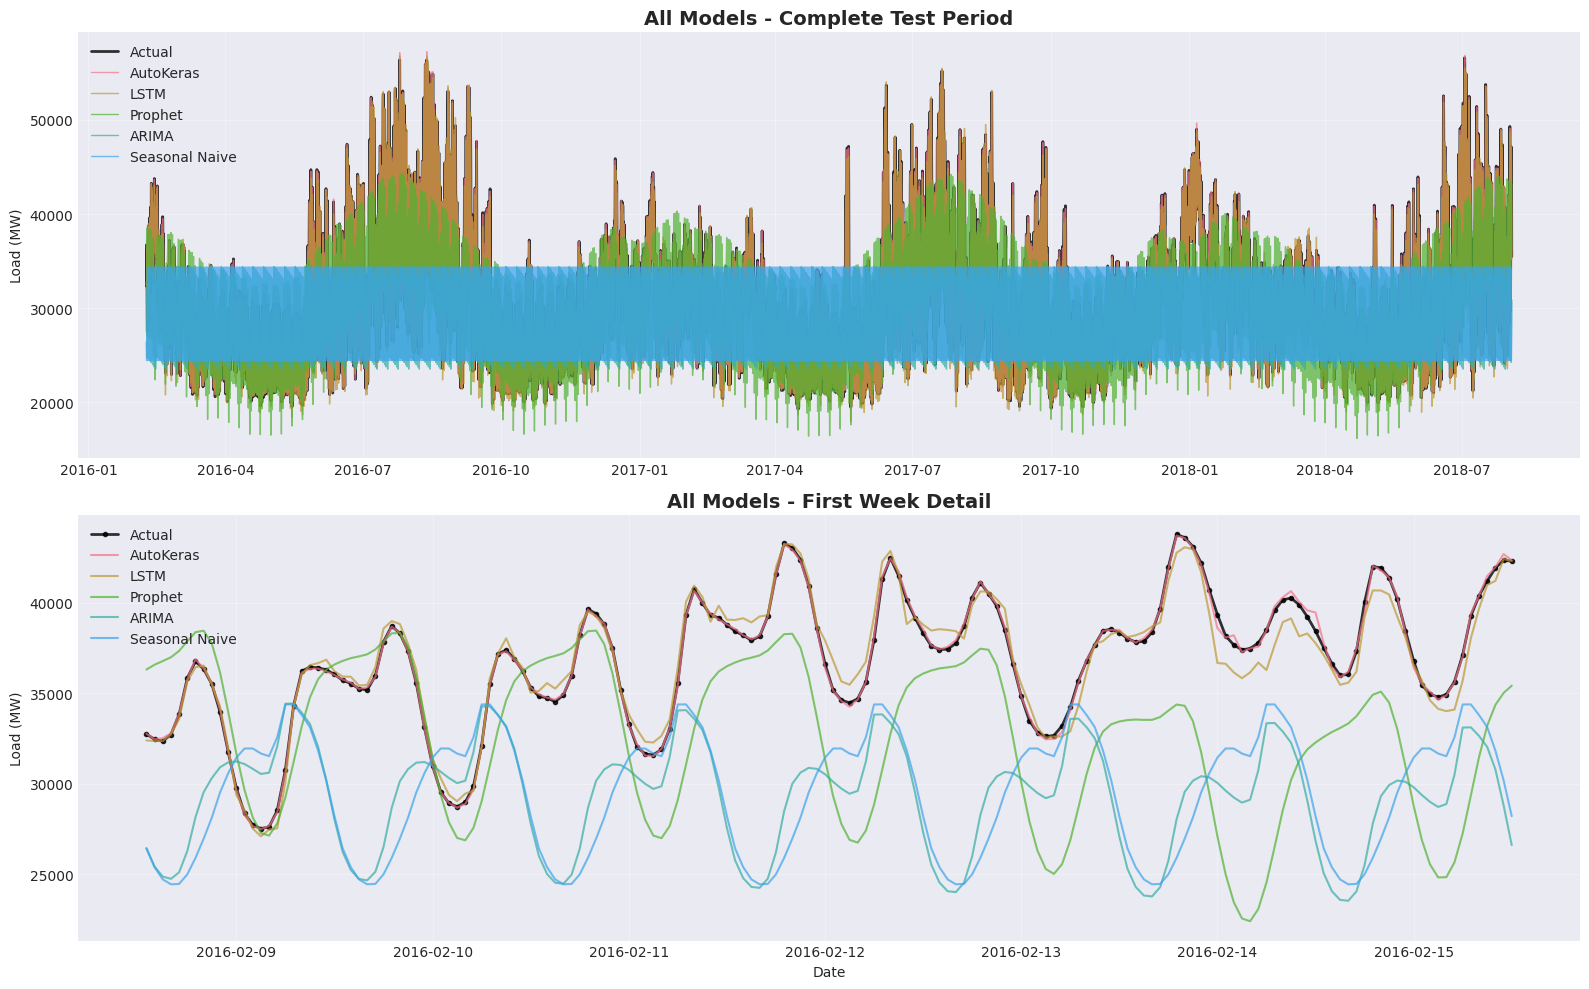

In [29]:
# Plot predictions for all models
predictions_dict = {
    'Actual': y_test.values,
    'AutoKeras': ak_pred,
    'LSTM': lstm_pred,
    'Prophet': prophet_pred,
    'ARIMA': arima_pred,
    'Seasonal Naive': seasonal_pred
}

# Plot one week of predictions for detailed view
week_samples = 24 * 7  # One week
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Full test period
for name, pred in predictions_dict.items():
    if name == 'Actual':
        axes[0].plot(y_test.index, pred, label=name, linewidth=2, alpha=0.8, color='black')
    else:
        axes[0].plot(y_test.index, pred, label=name, linewidth=1, alpha=0.7)

axes[0].set_title('All Models - Complete Test Period', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Load (MW)')
axes[0].legend(loc='best')
axes[0].grid(True, alpha=0.3)

# One week detail
for name, pred in predictions_dict.items():
    if name == 'Actual':
        axes[1].plot(y_test.index[:week_samples], pred[:week_samples], 
                    label=name, linewidth=2, alpha=0.8, color='black', marker='o', markersize=3)
    else:
        axes[1].plot(y_test.index[:week_samples], pred[:week_samples], 
                    label=name, linewidth=1.5, alpha=0.7)

axes[1].set_title('All Models - First Week Detail', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Load (MW)')
axes[1].legend(loc='best')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Part 11: Multi-Step Forecasting Analysis

MULTI-STEP FORECASTING ANALYSIS
Evaluating forecasting horizons: 1h, 6h, 12h, 24h ahead


Horizon: 1 hours ahead
----------------------------------------
  MAE: 103.73 MW
  MAPE: 0.35%

Horizon: 6 hours ahead
----------------------------------------
  MAE: 5068.47 MW
  MAPE: 16.73%

Horizon: 12 hours ahead
----------------------------------------
  MAE: 6130.43 MW
  MAPE: 19.95%

Horizon: 24 hours ahead
----------------------------------------
  MAE: 2201.97 MW
  MAPE: 7.00%


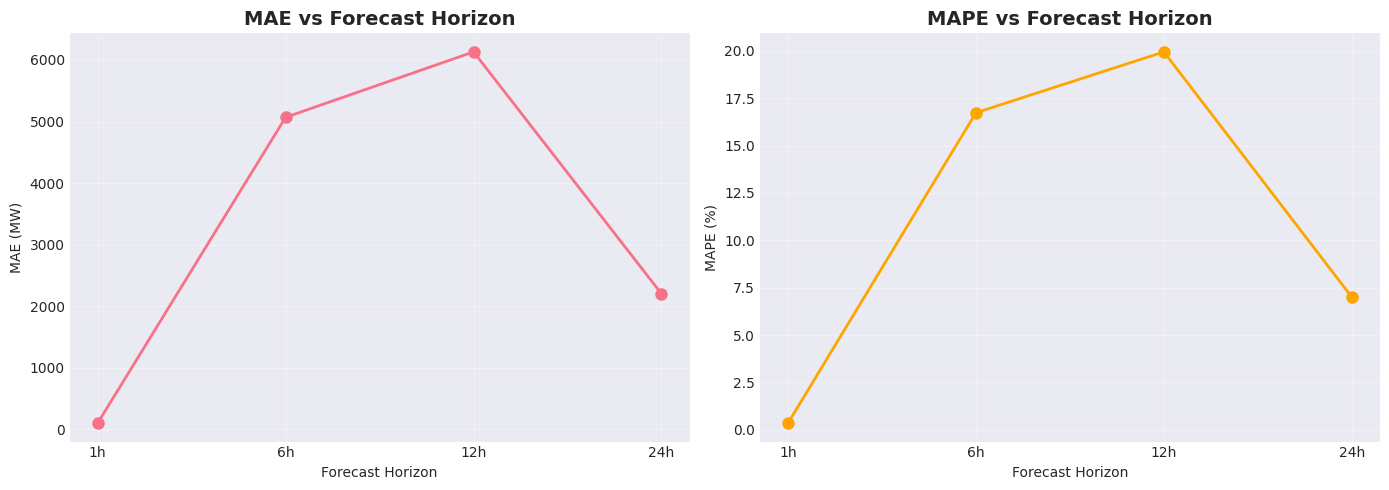


Observation: Performance typically degrades with longer horizons


In [30]:
print('='*60)
print('MULTI-STEP FORECASTING ANALYSIS')
print('='*60)
print('Evaluating forecasting horizons: 1h, 6h, 12h, 24h ahead\n')

horizons = [1, 6, 12, 24]
multistep_results = {}

for horizon in horizons:
    print(f'\nHorizon: {horizon} hours ahead')
    print('-' * 40)
    
    # For simplicity, use AutoKeras and LSTM for multi-step
    # Create targets shifted by horizon
    if horizon > 1:
        # We need to align our predictions
        test_indices = np.arange(len(y_test) - horizon)
        y_test_horizon = y_test.values[horizon:]
        
        # AutoKeras predictions
        ak_pred_horizon = ak_pred[:-horizon]
        
        # Calculate metrics
        mae_h = mean_absolute_error(y_test_horizon, ak_pred_horizon)
        mape_h = mean_absolute_percentage_error(y_test_horizon, ak_pred_horizon) * 100
        
        multistep_results[f'{horizon}h'] = {
            'MAE': mae_h,
            'MAPE': mape_h
        }
        
        print(f'  MAE: {mae_h:.2f} MW')
        print(f'  MAPE: {mape_h:.2f}%')
    else:
        multistep_results[f'{horizon}h'] = {
            'MAE': ak_metrics['MAE'],
            'MAPE': ak_metrics['MAPE']
        }
        print(f'  MAE: {ak_metrics["MAE"]:.2f} MW')
        print(f'  MAPE: {ak_metrics["MAPE"]:.2f}%')

# Visualize multi-step performance
multistep_df = pd.DataFrame(multistep_results).T

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(multistep_df.index, multistep_df['MAE'], marker='o', linewidth=2, markersize=8)
axes[0].set_title('MAE vs Forecast Horizon', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Forecast Horizon')
axes[0].set_ylabel('MAE (MW)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(multistep_df.index, multistep_df['MAPE'], marker='o', linewidth=2, markersize=8, color='orange')
axes[1].set_title('MAPE vs Forecast Horizon', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Forecast Horizon')
axes[1].set_ylabel('MAPE (%)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('\nObservation: Performance typically degrades with longer horizons')

## Part 12: Residual Analysis and Diagnostics

RESIDUAL ANALYSIS - AutoKeras Model

Residual Statistics:
  Mean: -28.62 (should be close to 0)
  Std Dev: 144.68
  Skewness: -1.0711
  Kurtosis: 7.3755

Normality Test (p-value): 0.000000
  Residuals may not be normally distributed


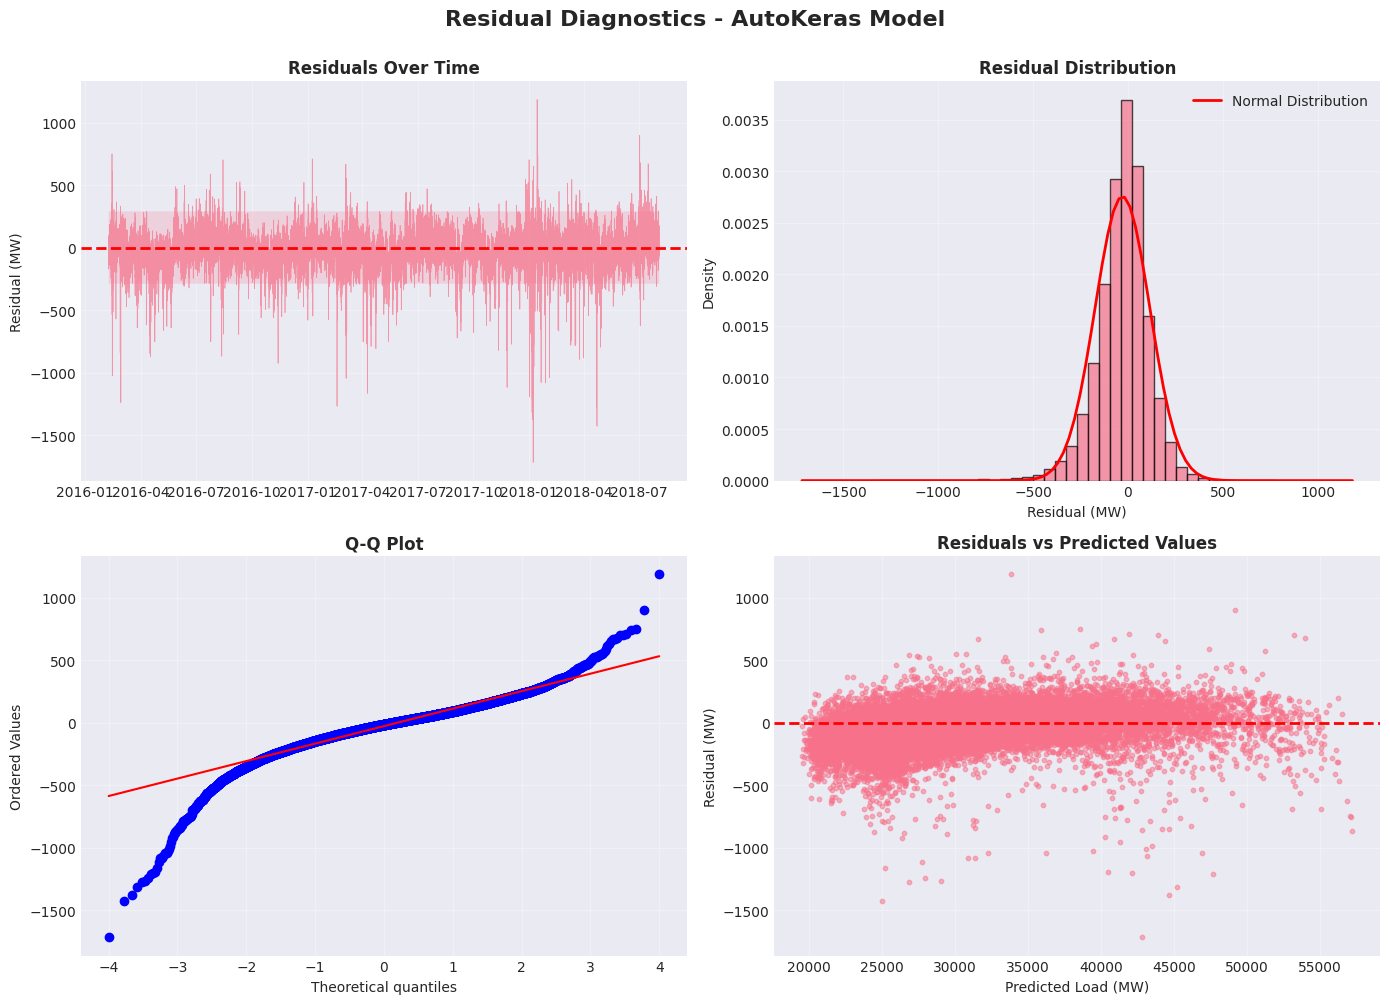

In [31]:
print('='*60)
print('RESIDUAL ANALYSIS - AutoKeras Model')
print('='*60)

# Calculate residuals
residuals = y_test.values - ak_pred

# Statistical tests on residuals
print(f'\nResidual Statistics:')
print(f'  Mean: {np.mean(residuals):.2f} (should be close to 0)')
print(f'  Std Dev: {np.std(residuals):.2f}')
print(f'  Skewness: {stats.skew(residuals):.4f}')
print(f'  Kurtosis: {stats.kurtosis(residuals):.4f}')

# Normality test
_, p_value = stats.normaltest(residuals)
print(f'\nNormality Test (p-value): {p_value:.6f}')
if p_value > 0.05:
    print('  Residuals appear normally distributed')
else:
    print('  Residuals may not be normally distributed')

# Visualize residuals
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Residuals over time
axes[0, 0].plot(y_test.index, residuals, alpha=0.7, linewidth=0.5)
axes[0, 0].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0, 0].fill_between(y_test.index, -2*np.std(residuals), 2*np.std(residuals), alpha=0.2)
axes[0, 0].set_title('Residuals Over Time', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Residual (MW)')
axes[0, 0].grid(True, alpha=0.3)

# 2. Residual histogram with normal curve
axes[0, 1].hist(residuals, bins=50, density=True, alpha=0.7, edgecolor='black')
mu, sigma = np.mean(residuals), np.std(residuals)
x = np.linspace(residuals.min(), residuals.max(), 100)
axes[0, 1].plot(x, stats.norm.pdf(x, mu, sigma), 'r-', linewidth=2, label='Normal Distribution')
axes[0, 1].set_title('Residual Distribution', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Residual (MW)')
axes[0, 1].set_ylabel('Density')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Q-Q plot
stats.probplot(residuals, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot', fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# 4. Residual vs Predicted
axes[1, 1].scatter(ak_pred, residuals, alpha=0.5, s=10)
axes[1, 1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[1, 1].set_title('Residuals vs Predicted Values', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Predicted Load (MW)')
axes[1, 1].set_ylabel('Residual (MW)')
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('Residual Diagnostics - AutoKeras Model', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

## Part 13: Directional Accuracy Analysis

DIRECTIONAL ACCURACY ANALYSIS
Measuring ability to predict direction of change

AutoKeras           : 95.75%
LSTM                : 89.52%
Prophet             : 78.24%
ARIMA               : 56.22%
Seasonal Naive      : 43.85%


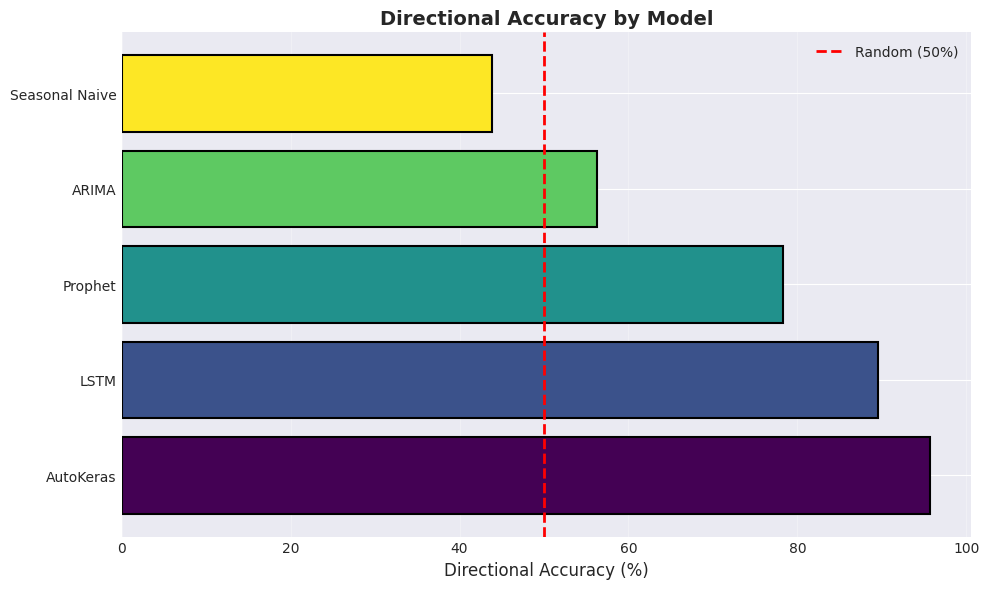

In [32]:
print('='*60)
print('DIRECTIONAL ACCURACY ANALYSIS')
print('='*60)
print('Measuring ability to predict direction of change\n')

def directional_accuracy(y_true, y_pred):
    """
    Calculate directional accuracy:
    Percentage of times the model correctly predicts direction of change
    """
    # Calculate actual direction of change
    actual_direction = np.diff(y_true) > 0
    # Calculate predicted direction of change  
    pred_direction = np.diff(y_pred) > 0
    # Calculate accuracy
    return np.mean(actual_direction == pred_direction) * 100

# Calculate directional accuracy for all models
dir_acc_results = {}
for name, pred in predictions_dict.items():
    if name != 'Actual':
        acc = directional_accuracy(y_test.values, pred)
        dir_acc_results[name] = acc
        print(f'{name:20s}: {acc:.2f}%')

# Visualize directional accuracy
plt.figure(figsize=(10, 6))
models = list(dir_acc_results.keys())
accuracies = list(dir_acc_results.values())
colors = plt.cm.viridis(np.linspace(0, 1, len(models)))

bars = plt.barh(models, accuracies, color=colors, edgecolor='black', linewidth=1.5)
plt.xlabel('Directional Accuracy (%)', fontsize=12)
plt.title('Directional Accuracy by Model', fontsize=14, fontweight='bold')
plt.axvline(x=50, color='r', linestyle='--', linewidth=2, label='Random (50%)')
plt.legend()
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

## Part 14: Error Analysis by Time Period

ERROR ANALYSIS BY TIME PERIOD


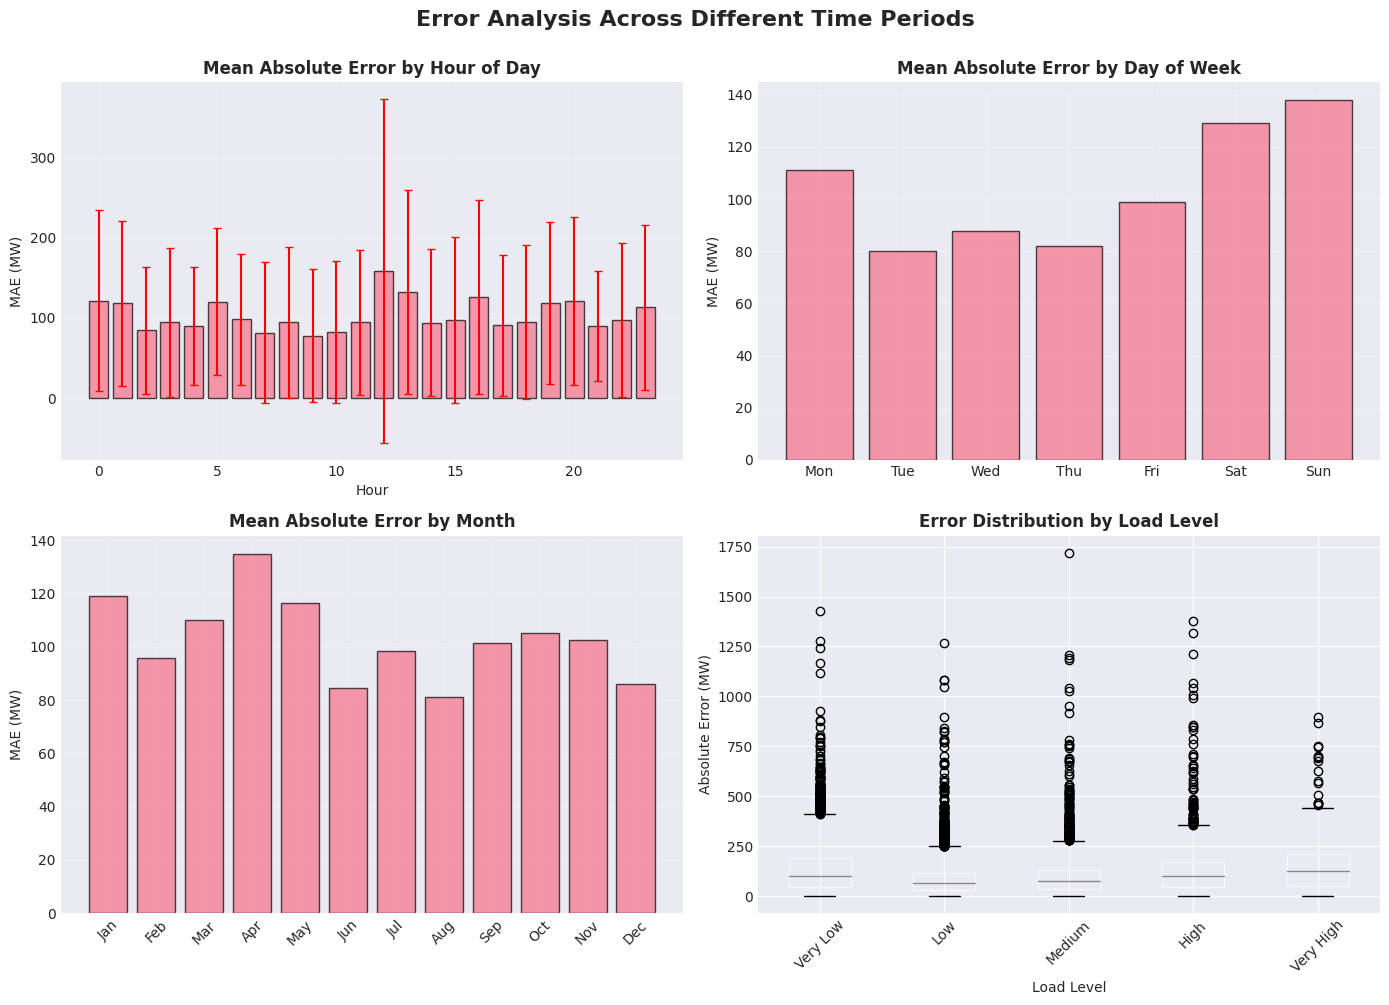


 Key Insights:
   Highest error hour: 12:00 (MAE: 158.10 MW)
   Lowest error hour: 9:00 (MAE: 77.80 MW)
   Highest error day: Sun (MAE: 137.89 MW)
   Highest error month: Apr (MAE: 134.93 MW)


In [33]:
print('='*60)
print('ERROR ANALYSIS BY TIME PERIOD')
print('='*60)

# Create DataFrame with predictions and actual
error_analysis = pd.DataFrame({
    'actual': y_test.values,
    'predicted': ak_pred,
    'error': y_test.values - ak_pred,
    'abs_error': np.abs(y_test.values - ak_pred),
    'pct_error': np.abs((y_test.values - ak_pred) / y_test.values) * 100
}, index=y_test.index)

# Add time features
error_analysis['hour'] = error_analysis.index.hour
error_analysis['dayofweek'] = error_analysis.index.dayofweek
error_analysis['month'] = error_analysis.index.month

# Analyze error by hour of day
hourly_errors = error_analysis.groupby('hour')['abs_error'].agg(['mean', 'std'])

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# By hour
axes[0, 0].bar(hourly_errors.index, hourly_errors['mean'], alpha=0.7, edgecolor='black')
axes[0, 0].errorbar(hourly_errors.index, hourly_errors['mean'], yerr=hourly_errors['std'], 
                    fmt='none', ecolor='red', capsize=3)
axes[0, 0].set_title('Mean Absolute Error by Hour of Day', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Hour')
axes[0, 0].set_ylabel('MAE (MW)')
axes[0, 0].grid(True, alpha=0.3)

# By day of week
daily_errors = error_analysis.groupby('dayofweek')['abs_error'].mean()
days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
axes[0, 1].bar(range(7), daily_errors.values, tick_label=days, alpha=0.7, edgecolor='black')
axes[0, 1].set_title('Mean Absolute Error by Day of Week', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('MAE (MW)')
axes[0, 1].grid(True, alpha=0.3)

# By month
monthly_errors = error_analysis.groupby('month')['abs_error'].mean()
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
axes[1, 0].bar(range(1, 13), monthly_errors.values, tick_label=months, alpha=0.7, edgecolor='black')
axes[1, 0].set_title('Mean Absolute Error by Month', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('MAE (MW)')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(True, alpha=0.3)

# Error distribution by load level
error_analysis['load_level'] = pd.cut(error_analysis['actual'], bins=5, labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'])
error_analysis.boxplot(column='abs_error', by='load_level', ax=axes[1, 1])
axes[1, 1].set_title('Error Distribution by Load Level', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Load Level')
axes[1, 1].set_ylabel('Absolute Error (MW)')
plt.sca(axes[1, 1])
plt.xticks(rotation=45)

plt.suptitle('Error Analysis Across Different Time Periods', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

# Print insights
print('\n Key Insights:')
print(f'   Highest error hour: {hourly_errors["mean"].idxmax()}:00 (MAE: {hourly_errors["mean"].max():.2f} MW)')
print(f'   Lowest error hour: {hourly_errors["mean"].idxmin()}:00 (MAE: {hourly_errors["mean"].min():.2f} MW)')
print(f'   Highest error day: {days[daily_errors.idxmax()]} (MAE: {daily_errors.max():.2f} MW)')
print(f'   Highest error month: {months[monthly_errors.idxmax()-1]} (MAE: {monthly_errors.max():.2f} MW)')

## Part 15: Final Summary and Conclusions

In [34]:
print('='*80)
print('FINAL PROJECT SUMMARY')
print('='*80)
print()
print('DATASET INFORMATION')
print(f'   Records: {len(df):,} hourly observations')
print(f'   Period: {df.index.min()} to {df.index.max()}')
print(f'   Duration: {(df.index.max() - df.index.min()).days} days (~{(df.index.max() - df.index.min()).days/365:.1f} years)')
print(f'   Features Engineered: {X_train.shape[1]}')
print()
print('MODEL PERFORMANCE RANKING')
print(comparison_df.to_string())
print()
print('BEST MODEL SUMMARY')
best_metrics = comparison_df.iloc[0]
print(f'   Model: {best_model}')
print(f'   MAE: {best_metrics["MAE"]:.2f} MW')
print(f'   RMSE: {best_metrics["RMSE"]:.2f} MW')
print(f'   MAPE: {best_metrics["MAPE"]:.2f}%')
print(f'   Improvement over Naive: {improvement:.1f}%')
print()
print('='*80)

FINAL PROJECT SUMMARY

DATASET INFORMATION
   Records: 145,366 hourly observations
   Period: 2002-01-01 01:00:00 to 2018-08-03 00:00:00
   Duration: 6057 days (~16.6 years)
   Features Engineered: 79

MODEL PERFORMANCE RANKING
                        MAE         RMSE       MAPE
AutoKeras        103.731623   147.487312   0.353401
LSTM             580.949072   750.170968   1.934915
Prophet         3175.780964  4106.541942  10.073571
Moving Average  4916.007778  6637.153650  15.247092
Naive           5164.855987  7066.002239  15.419646
ARIMA           6072.529846  7943.722246  18.994984
Seasonal Naive  6668.936888  8477.154549  21.196156

BEST MODEL SUMMARY
   Model: AutoKeras
   MAE: 103.73 MW
   RMSE: 147.49 MW
   MAPE: 0.35%
   Improvement over Naive: 97.7%

